In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [3]:
# --- LOAD DATA ---
train_path = 'Phishing_URL_ds_feature_engineered_train.csv'
test_path = 'Phishing_URL_ds_feature_engineered_test.csv'

df_train = pd.read_csv(train_path)
df_test = pd.read_csv(test_path)

print(f"Train Shape: {df_train.shape}")
print(f"Test Shape:  {df_test.shape}")

Train Shape: (156808, 40)
Test Shape:  (67204, 40)


In [4]:



# Define Features (X) and Target (y)
X_train = df_train.drop(columns=['label'])
y_train = df_train['label']

X_test = df_test.drop(columns=['label'])
y_test = df_test['label']


In [6]:
# max_iter=2000 ensures it has enough time to converge
log_reg = LogisticRegression(random_state=42, max_iter=2000) 
log_reg.fit(X_train, y_train)

# Predict
y_pred = log_reg.predict(X_test)
y_prob = log_reg.predict_proba(X_test)[:, 1] # For ROC Curve later


--- MODEL PERFORMANCE ---
Accuracy Score: 99.67%

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     28760
         1.0       1.00      1.00      1.00     38444

    accuracy                           1.00     67204
   macro avg       1.00      1.00      1.00     67204
weighted avg       1.00      1.00      1.00     67204



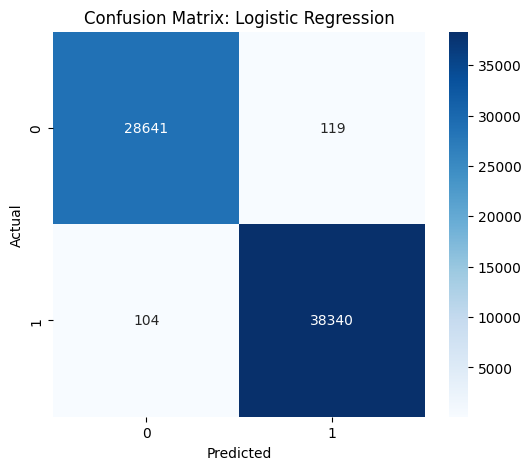

In [7]:
print("\n--- MODEL PERFORMANCE ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred)*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix Visualization
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix: Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [9]:
# Which features did the model find most important?
coeffs = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': log_reg.coef_[0]
})
coeffs['Abs_Coefficient'] = coeffs['Coefficient'].abs()
coeffs = coeffs.sort_values(by='Abs_Coefficient', ascending=False).head(10)

print("\n--- TOP 10 MOST IMPORTANT FEATURES ---")
print(coeffs[['Feature', 'Coefficient']])


--- TOP 10 MOST IMPORTANT FEATURES ---
                  Feature  Coefficient
26              NoOfImage     4.257915
29            NoOfSelfRef     3.884415
17  SpacialCharRatioInURL    -2.597761
10       LetterRatioInURL    -2.587433
28                 NoOfJS     1.877793
36           HasSocialNet     1.365126
12        DegitRatioInURL    -1.275948
6           NoOfSubDomain     1.217670
2                     TLD     1.107320
38         HasDescription     0.963934
